# RNN(순환신경망)
- 이전 시점의 정보를 현재 시점의 계산에 반영하는 구조

- 첫 번째 입력이 들어왔을 때
    - 초기의 상태(h_0 = 0)와 입력에 대한 상태(h_1)로 계산
- 두 번째 입력이 들어왔을 때
    - 이전의 상태(h_1)과 결합해서 계산 (h_2)
- 반복 작업이 완료가 되었을 때
    - 마지막 상태(h_T) 생성

- 매개변수
    - input_size
        - 각 시점에서 입력의 피쳐의 개수
    - hidden_size
        - 은닉층(출력)의 크기
    - num_layers
        - 기본값 : 1
        - RNN 층의 개수 (층이 깊을수록 복잡한 패턴이 생성)
        - 개수가 늘어날수록 시간이 증가하고 과적합의 위험성이 존재
        - 1~3 정도 사용을 할 때 1부터 개수를 1씩 늘려가면서 사용
    - nonlinearity
        - 기본값 : 'tanh'
        - 비선형 활성화 함수를 선택 
    - bias
        - 기본값 : True
        - 각 가중치에 편향 항을 추가 여부
    - batch_first 
        - 기본값 : False
        - 입력 텐서 첫 차원이 배치인지 여부
    - dropout
        - 기본값 : 0.0
        - 층 사이에 드랍아웃의 적용 비율 -> 층이 2개 이상에 사용
    - bidirectional
        - 기본값 : False
        - 양방향 RNN 사용할지 여부 (순방향이 기본, 역방향을 사용할지 지정)
- 매개변수의 유의점
    - hidden_size
        - 너무 적은 경우라면 정보가 부족, 너무 큰 경우에는 과적합
        - 일반적으로는 32 ~ 128
    - num_layers
        - 시간의 복잡도에 따라 1 ~ 3 정도 사용
        - 1부터 테스트를 돌려서 교차 검증
    - nonlinearity
        - 'tanh' 의 기본 값이고 'relu'로 변경하면 시간은 감소할 수 있지만 불안정
    - dropout
        - 층이 2개 이상인 경우에 사용
        - 과적합 방지를 위해 0.2 ~ 0.5 사용 (권장)

In [130]:
# RNN 기본형
# 샘플 데이터를 생성해서 코드 작성
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [131]:
# 랜덤 일관성 설정
np.random.seed(42)
torch.manual_seed(42)

In [132]:
# 사인 그래프를 생성 + 노이즈
idx = torch.arange(3000).float()
data = torch.sin(2 * math.pi * 0.02 * idx) + 0.05 * torch.rand(3000)

In [133]:
data

tensor([ 0.0441,  0.1711,  0.2678,  ..., -0.3259, -0.2480, -0.0964])

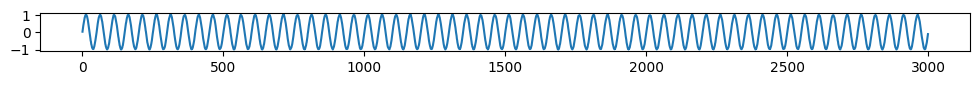

In [134]:
plt.figure(figsize=(12, 0.5))
plt.plot(idx, data)
plt.show()

In [135]:
# 연속성이 있는 시계열 데이터를 기준으로 train, test 를 8:2로 나눠준다.
# 앞부분 80%, 뒷부분 20%
# 전체 데이터의 길이에서 0.8을 곱한 idx의 값이 데이터의 경계
split_idx = int(len(data) * 0.8)
train_data = data[ : split_idx]     # 학습 데이터(구간)
test_data = data[split_idx : ]      # 평가 데이터(구간)

In [136]:
scaler = StandardScaler()

train_data = scaler.fit_transform(train_data.reshape(-1, 1))
test_data = scaler.transform(test_data.reshape(-1, 1))

In [137]:
test_data

array([[-0.02667372],
       [ 0.15671405],
       [ 0.33731958],
       [ 0.54180614],
       [ 0.69265204],
       [ 0.817288  ],
       [ 0.9919208 ],
       [ 1.06711873],
       [ 1.16454728],
       [ 1.28650413],
       [ 1.32463364],
       [ 1.39827636],
       [ 1.44038202],
       [ 1.3937553 ],
       [ 1.36357229],
       [ 1.35738462],
       [ 1.24689149],
       [ 1.22482389],
       [ 1.07234358],
       [ 0.98463928],
       [ 0.80280236],
       [ 0.6571747 ],
       [ 0.52443074],
       [ 0.36434965],
       [ 0.20494197],
       [ 0.03001864],
       [-0.17862648],
       [-0.35541841],
       [-0.51373957],
       [-0.6883212 ],
       [-0.82871888],
       [-1.0000762 ],
       [-1.11704616],
       [-1.16813743],
       [-1.2984522 ],
       [-1.31531154],
       [-1.38335949],
       [-1.40086857],
       [-1.37736869],
       [-1.40687199],
       [-1.34868759],
       [-1.27153893],
       [-1.18025231],
       [-1.12240002],
       [-0.95404559],
       [-0

In [138]:
# data들을 torch에서 사용하기 위해 tensor의 형태로 변환
train_data = torch.tensor(train_data.squeeze(-1), dtype=torch.float)
test_data = torch.tensor(test_data.squeeze(-1), dtype=torch.float32)

In [139]:
print(type(train_data))

<class 'torch.Tensor'>


In [140]:
class WindowDataset(Dataset):
    # 단변량 시계열에서 입력 값 정답 값을 만드는 Dataset
    def __init__(self, _data, _window):
        # _data : (N, ) 형태의 1차원 tensor 데이터
        # _window: 과거의 몇개의 데이터를 볼 것인가? (구간 설정)
        self.data = _data
        self.window = _window
        # 유효 샘플의 개수 중 학습 데이터의 개수는 data의 전체 길이에서 -1
        # 입력 데이터는 전체 길이 - 윈도우
        self.n = len(_data) - _window

    # 두 개의 특수 함수들은 DataLoader에서 자동으로 호출해서 사용이 되는 부분
    def __len__(self):
        return max(self.n, 0)
    def __getitem__(self, idx):
        # 변환
        # x -> 입력데이터 --> 문제
        # y -> 입력데이터 다음 행의 데이터 --> 정답
        x = self.data[idx: idx+self.window].unsqueeze(-1) # (window, ) -> (window, 1)
        y = self.data[idx + self.window].unsqueeze(-1)
        return x, y

In [141]:
# class 생성
# 구간 설정 값
window = 50
train_ds = WindowDataset(train_data, window)
val_ds = WindowDataset(test_data, window)

In [142]:
# DataLoader : 학습 데이터를 구간 별로 뽑아서 새로운 리스트형 데이터를 생성
train_dl = DataLoader(train_ds, shuffle=True, drop_last=True, batch_size=64)
val_dl = DataLoader(val_ds, shuffle=False, drop_last=False, batch_size=256)

In [143]:
train_dl

### DataLoader 
- 파이토치에서 Dataset들을 효율적으로 배치 단위로 꺼내주는 반복자
- 반복 학습 루프에 맞는 형태의 데이터셋을 공급해주는 역할
- 배치 생성 -> Dataset들을 모아서 텐서의 형태로 몪어줌
- shuffle -> 에폭마다 데이터의 순서를 랜덤하게 변경
- drop_last -> window에 맞게 구간을 나누고 마지막 구간의 데이터의 개수가 작은 경우 해당 배치를 제거
- pin_memory -> GPU 사용 시 True로 변경하면 CPU -> GPU 전송이 빨라짐

In [144]:
# RNN class 정의
class RNNReg(nn.Module):
    # 해당 class에서 정의되는 함수는 생성자함수, forward()함수

    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers = 1,
            nonlinearity = 'tanh',
            dropout = 0.0,
            bidirectional = False,
            batch_first = True
    ):
        # 부모 클래스의 생성자 함수 호출
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout,
            bidirectional=bidirectional,
            batch_first=batch_first
        )
        # bidirectional의 값이 False인 경우에는 hidden_size를 사용
        # 만약 True라면 hidden_size * 2
        out_features = hidden_size * (2 if bidirectional else 1)
        self.head = nn.Linear(out_features, 1)   # 1차원 스칼라 회귀
    def forward(self, X):
        # out -> 모든 시점에서의 은닉층의 값(결과)
        # h_n -> 마지막 시점에서의 은닉층의 값(결과) -> 층이 존재하면 층별 마지막 값 -> 시계열 분석은 마지막 시점을 사용
        out, h_n = self.rnn(X)
        # 가장 마지막 은닉의 값을 사용(마지막 층의 값)
        last_hidden = h_n[-1]
        res = self.head(last_hidden)
        return res

In [145]:
rnn_model = RNNReg(
    input_size = 1, hidden_size = 64
)
rnn_model

RNNReg(
  (rnn): RNN(1, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [146]:
# 회귀 분석 -> 손실 함수 -> MSE
criterion = nn.MSELoss()
# 옵티마이저 설정
optimizer = torch.optim.Adam(rnn_model.parameters(), lr = 0.001)
# loss의 미분 폭주 방지용 설정
max_grad_norm = 1.0

# 검증 단계 함수 생성
def evaliate_mse(dataloader):
    rnn_model.eval()
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for x, y in dataloader:
            x = x.float()
            y = y.float()
            yhat = rnn_model(x)
            loss = criterion(yhat, y)
            # 총 손실
            total_loss += loss.item() * y.size(0)   
            # loss.item() : 손실의 평균
            # y.size(0) : 개수
            total_n += y.size(0)
    return total_loss / max(total_n, 1)

In [147]:
# 반복 학습 루프

# 학습 데이터의 loss들과 검증 데이터의 loss 들을 저장 -> 시각화
train_history = []
val_history = []

for epoch in range(20):
    rnn_model.train()
    running = 0.0
    n_seen = 0

    for x, y in train_dl:
        x = x.float()
        y = y.float()

        optimizer.zero_grad()
        yhat = rnn_model(x)
        loss = criterion(yhat, y)
        loss.backward()
        # 미분값 폭주 방지
        nn.utils.clip_grad_norm_(rnn_model.parameters(), max_grad_norm)

        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / max(n_seen, 1)
    val_mse = evaliate_mse(val_dl)
    train_history.append(train_mse)
    val_history.append(val_mse)
    print(f"Epoch : {epoch + 1}, train_mse : {round(train_mse, 5)}, val_mse : {round(val_mse, 5)}")

Epoch : 1, train_mse : 0.35237, val_mse : 0.01107
Epoch : 2, train_mse : 0.00652, val_mse : 0.00386
Epoch : 3, train_mse : 0.00334, val_mse : 0.00258
Epoch : 4, train_mse : 0.00232, val_mse : 0.00215
Epoch : 5, train_mse : 0.00194, val_mse : 0.00195
Epoch : 6, train_mse : 0.00168, val_mse : 0.00144
Epoch : 7, train_mse : 0.00148, val_mse : 0.00139
Epoch : 8, train_mse : 0.00137, val_mse : 0.00134
Epoch : 9, train_mse : 0.00145, val_mse : 0.00126
Epoch : 10, train_mse : 0.00116, val_mse : 0.00122
Epoch : 11, train_mse : 0.00107, val_mse : 0.00093
Epoch : 12, train_mse : 0.00097, val_mse : 0.00076
Epoch : 13, train_mse : 0.00102, val_mse : 0.00094
Epoch : 14, train_mse : 0.00092, val_mse : 0.00084
Epoch : 15, train_mse : 0.00097, val_mse : 0.00087
Epoch : 16, train_mse : 0.0009, val_mse : 0.00096
Epoch : 17, train_mse : 0.00085, val_mse : 0.00074
Epoch : 18, train_mse : 0.00087, val_mse : 0.00084
Epoch : 19, train_mse : 0.00082, val_mse : 0.00072
Epoch : 20, train_mse : 0.00076, val_mse 

<function matplotlib.pyplot.show(close=None, block=None)>

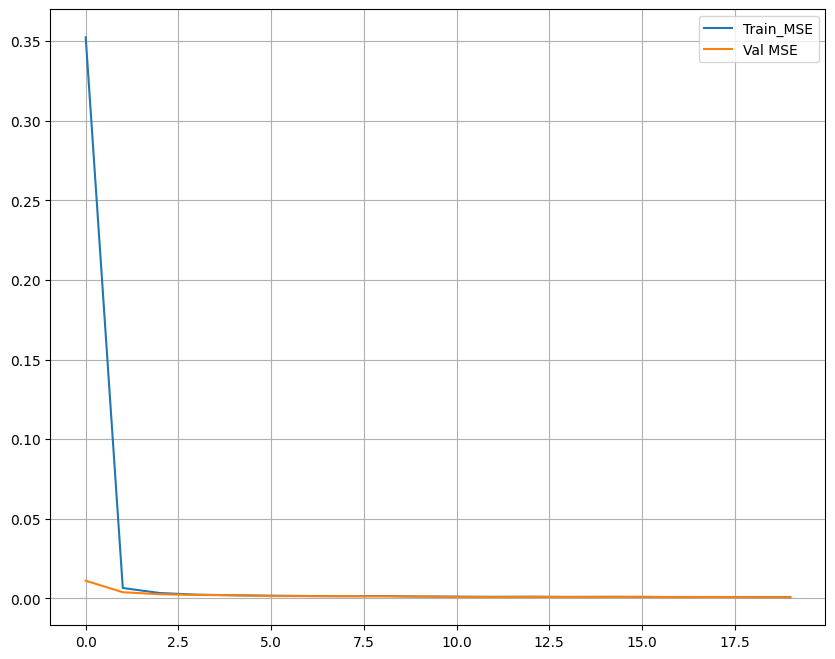

In [149]:
# MSE의 곡선을 그래프로 확인
plt.figure(figsize=(10, 8))
plt.plot(train_history, label='Train_MSE')
plt.plot(val_history, label = 'Val MSE')
plt.legend()
plt.grid(True)
plt.show


In [151]:
# 검증 구간의 데이터와 실제의 예측 데이터를 비교 시각화
rnn_model.eval()
preds = []
trues = []

with torch.no_grad():
    for x, y in val_dl:
        x = x.float()
        y = y.float()
        yhat = rnn_model(x)
        preds.append(yhat.cpu())
        trues.append(y.cpu())

[tensor([[ 0.0116],
         [ 0.1841],
         [ 0.3580],
         [ 0.5388],
         [ 0.7014],
         [ 0.8387],
         [ 0.9529],
         [ 1.0709],
         [ 1.1962],
         [ 1.2983],
         [ 1.3613],
         [ 1.3905],
         [ 1.4128],
         [ 1.4075],
         [ 1.3940],
         [ 1.3515],
         [ 1.2752],
         [ 1.1832],
         [ 1.0822],
         [ 0.9555],
         [ 0.8194],
         [ 0.6522],
         [ 0.4843],
         [ 0.3061],
         [ 0.1417],
         [-0.0213],
         [-0.2041],
         [-0.3771],
         [-0.5251],
         [-0.6736],
         [-0.8306],
         [-0.9860],
         [-1.1157],
         [-1.2156],
         [-1.2886],
         [-1.3563],
         [-1.4055],
         [-1.4347],
         [-1.4271],
         [-1.3842],
         [-1.3264],
         [-1.2638],
         [-1.1825],
         [-1.0718],
         [-0.9591],
         [-0.8375],
         [-0.6987],
         [-0.5352],
         [-0.3514],
         [-0.1620],


In [158]:
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

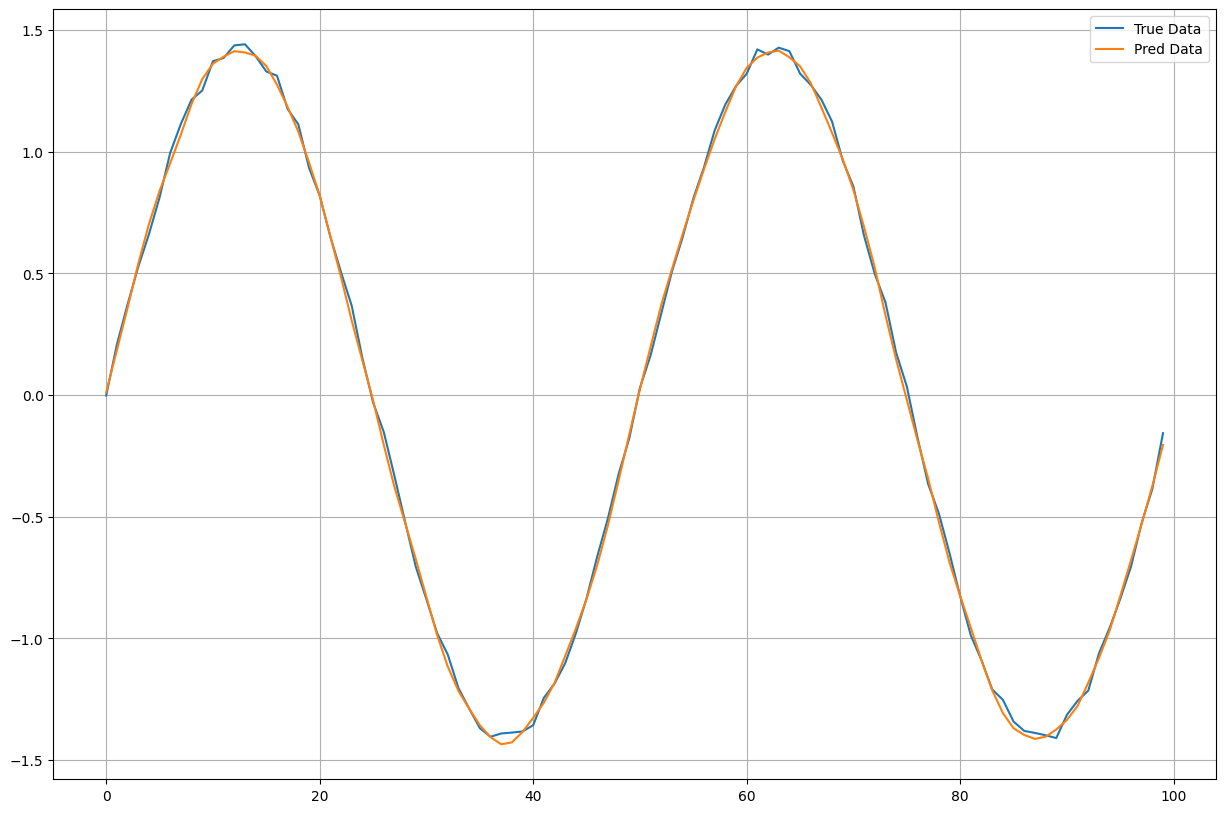

In [164]:
plt.figure(figsize=(15, 10))
plt.plot(trues[:100], label='True Data')
plt.plot(preds[:100], label='Pred Data')
plt.legend()
plt.grid(True)
plt.show()